In [1]:
import pandas as pd

skani_results = pd.read_csv("../../output/simulated_data_wrong_reference/Ecoli_ANI_values.tsv", sep="\t")

In [2]:
skani_results.head()

,Ref_file,Query_file,ANI,Align_fraction_ref,Align_fraction_query,Ref_name,Query_name
0,./data/reference/Ecoli/GCF_018512185.1.fna,./data/reference/Ecoli_K12_MG1655.fasta,99.99,90.95,99.68,NZ_JAFFIC010000003.1 Escherichia coli strain J...,NC_000913.3 Escherichia coli str. K-12 substr....
1,./data/reference/Ecoli/GCF_002458255.1.fna,./data/reference/Ecoli_K12_MG1655.fasta,99.99,96.67,97.69,NZ_NJTR01000100.1 Escherichia coli strain MOD1...,NC_000913.3 Escherichia coli str. K-12 substr....
2,./data/reference/Ecoli/GCF_021547135.1.fna,./data/reference/Ecoli_K12_MG1655.fasta,99.72,90.65,93.53,NZ_JAKFSJ010000100.1 Escherichia coli strain 5...,NC_000913.3 Escherichia coli str. K-12 substr....
3,./data/reference/Ecoli/GCA_900195655.1.fna,./data/reference/Ecoli_K12_MG1655.fasta,99.62,85.13,91.51,FZGG01000553.1 Escherichia coli isolate F1_402...,NC_000913.3 Escherichia coli str. K-12 substr....
4,./data/reference/Ecoli/GCF_016785425.1.fna,./data/reference/Ecoli_K12_MG1655.fasta,99.55,85.14,92.72,NZ_JADBFA010000100.1 Escherichia coli strain B...,NC_000913.3 Escherichia coli str. K-12 substr....


In [3]:
ani_values = []
af_values = []
error_rate_values = []


for i in range(len(skani_results)):
    # Get reference info from skani results
    ref = skani_results.iloc[i]["Ref_file"]
    ref_accession = ref.split("/")[-1].split(".fna")[0]
    ani = skani_results.iloc[i]["ANI"]
    af = skani_results.iloc[i]["Align_fraction_ref"]

    # Get read identity from the corresponding mapping results
    mapping_results = pd.read_csv(f"../../output/simulated_data_wrong_reference/{ref_accession}.summary_identity_stats.csv")
    read_identity = mapping_results["identity"].item()

    ani_values.append(ani)
    af_values.append(af)
    error_rate_values.append(1 - read_identity)

<>:13: SyntaxWarning: invalid escape sequence '\i'
<>:14: SyntaxWarning: invalid escape sequence '\i'
<>:13: SyntaxWarning: invalid escape sequence '\i'
<>:14: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_4080587/1173807600.py:13: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel("ANI vs. $\it{E. coli}$ K-12 MG1655 (%)")
/tmp/ipykernel_4080587/1173807600.py:14: SyntaxWarning: invalid escape sequence '\i'
  plt.title("Estimated error rate with other $\it{E. coli}$ references")


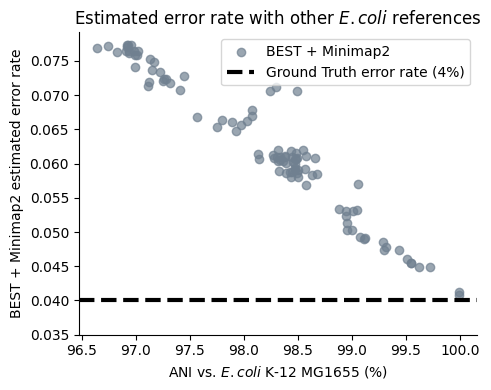

Bad pipe message: %s [b'\xfbK\xefMQ\xbb\x82\xb8\x03\xc1\x1f T\xe9w\x0f~5\x00\x02\xbc\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00\x1e\x00\x1f\x00 \x00!\x00"\x00#\x00$\x00%\x00&\x00\'\x00(\x00)\x00*\x00+\x00,\x00-\x00.\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x8a\x00\x8b\x00\x8c\x00\x8d\x00\x8e\x00\x8f\x00\x90\x00\x91\x00\x92\x00\x93\x00\x94\x00\x95\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xa8\x00\xa9\x00\xaa\x00', b'\xac\x00\xad\x00\xae\x00\xaf\x00\xb0\x00\xb1\x00\xb2\x00\xb3\x00\xb4\x00\xb5\x00\xb6\x00\xb7\x00\xb8\x00\xb9\x00\xba\x00\xbb\x00\x

In [ ]:
# Plot a scatter plot of Read Identity vs ANI

import matplotlib.pyplot as plt
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})
plt.figure(figsize=(5, 4))

plt.scatter(ani_values, error_rate_values, alpha=0.7, color='slategray', label='BEST + Minimap2')

# plot a horizontal line at y=0.04
plt.axhline(y=0.04, color='black', linewidth=3, linestyle='--', label='Ground Truth error rate (4%)')
plt.legend()
plt.ylabel("BEST + Minimap2 estimated error rate")
plt.xlabel("ANI vs. $\it{E. coli}$ K-12 MG1655 (%)")
plt.title("Estimated error rate with other $\it{E. coli}$ references")
plt.tight_layout()
plt.ylim(ymin=0.035)
plt.savefig("../../figures/minimap_with_other_strain.svg")